# Semantic Segmentation using Fully Convolutional Layers

The first approach to performing Semantic Segmentation using a deep neural network was proposed in the 2015 CVPR paper Fully Convolutional Networks for Semantic Segmentation by Jonathan Long, Evan Shelhamer, and Trevor Darrell which will be implemented in this notebook.

Since that time, several other architectures have been developed for semantic segmentation, such as UNet and DeepLabV3+. However, the simplicity of the FCN architecture is an ideal place to start for introducing the topic and the general approach used to achieve semantic segmentation.

Semantic segmentation is closely related to image classification, with the main difference being that every pixel in the image is classified as opposed to a single label assigned to the entire image. In semantic segmentation, the training data "labels" are represented as segmentation masks where every pixel in the mask is assigned to a unique class.

There are several metrics and loss functions that can be used for semantic segmentation, but in this notebook, we will use pixel accuracy as the metric and cross-entropy as the loss function.

## FCN
Fully Convolutional Networks, or FCNs, are a type of neural network that is mainly utilized for semantic segmentation. Convolution, pooling, and upsampling are the only layers used. Because wide layers aren't used, there are fewer parameters (making the networks faster to train). This also means that an FCN can handle a wide range of image sizes since there is no longer a size constraint imposed by the fully connected layers.

The FCN network has a downsampling path (also known as an encoder) for extracting and interpreting the context (image to feature maps), as well as an upsampling path (decoder) that uses 1x1 convolution to limit the depth of the output map to the number of classes, and transposed convolution for upsampling and localization. An important feature of transposed convolutions is that the filter parameters are learned.


<img src="https://opencv.org/wp-content/uploads/2022/07/c4-05-fcn-architecture.png" width=1000>

* FCNs also use **1x1 convolutions** prior to upsampling, which maintains the same spatial size of the feature maps while reducing the number of channels in the network to produce a final segmentation map with a depth that is equal to the number of classes. This is sometimes referred to as "channel pooling" since it is often used to reduce the number of channels in the network.
<br><br>
* The figure below depicts the three main components used in FCNs, which begins with a **CNN** to extract features, followed by a **1x1 convolution** layer which transforms the number of channels in the network to the number of classes, and then finally **transposed convolution**, which upsamples the spatial size of the feature maps to back to the original size of the input image.

<img src="https://opencv.org/wp-content/uploads/2022/07/c4-05-fcn-architecture-blocks.png" width=1000>

### Versions of FCN

There are three versions of FCN described in the original research paper related to the upsampling portion of the network (also referred to as the "decoder"). They are:

* FCN-32s: Upsample the feature map from the final convolutional layer directly by using a single transposed convolution layer with a stride of 32.
* FCN-16s: Combines predictions from both the final layer and the fourth Max Pooling layer (pool4) layer, at stride 16. This helps the network predict finer details while retaining high-level semantic information.
* FCN-8s: Combines predictions from both the third and fourth Max Pooling layers at stride 8. This gives the best results.

The following figure summarizes the upsampling approach for all three algorithms. The use of data from prior layers in the network in FCN-16s and FCN-8s is referred to as "skip layer fusion" in the original research paper. Connections like these are also often referred to as skip connections.

<img src="https://opencv.org/wp-content/uploads/2022/07/c4-05-fcn-32s-16s-8s.png">

In [1]:
import cv2
import numpy as np
from pathlib import Path
import albumentations as A
from typing import Tuple, List, Dict
from dataclasses import dataclass

import tensorflow as tf
import keras
from keras import Input, Sequential, Model
from keras.layers import Activation, Conv2D, Conv2DTranspose, MaxPool2D
from keras.utils import PyDataset
from keras.optimizers import Adam

import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter, MultipleLocator

In [2]:
import os


def system_config(seed_value: int = 3) -> None:
    np.random.seed(seed_value)
    tf.random.set_seed(seed=seed_value)

    gpu_devices_list = tf.config.list_physical_devices("GPU")
    if len(gpu_devices_list) > 0:
        print("Using GPU")
        os.environ["CUDA_VISIBLE_DEVIDES"] = "0"
        os.environ["TF_CUDNN_DETERMINISTIC"] = "1"
        os.environ["TF_USE_CEDNN"] = "true"

        tf.config.experimental.set_visible_devices(gpu_devices_list[0], "GPU")
        tf.config.experimental.set_memory_growth(gpu_devices_list[0], True)
    else:
        print("Using CPU")

In [3]:
system_config(seed_value=7)

Using CPU


### Dataset Retrieval

In [4]:
import requests
import zipfile


def download_file(url: str, save_path: Path) -> None:
    file = requests.get(url)
    open(save_path, "wb").write(file.content)


def unzip_file(zipped_file) -> None:
    try:
        with zipfile.ZipFile(zipped_file) as z:
            z.extractall("./")
            print("Extracted all files from ", zipped_file)
    except:
        print("Invalid file: ", zipped_file)


def download_unzip_file(url: str, save_path: Path) -> None:
    if save_path.exists():
        print("File already downloaded and extracted")
        return

    download_file(url=url, save_path=save_path)
    unzip_file(save_path)

In [5]:
PARENT = Path().resolve()
DATASET = PARENT / "dataset.zip"
download_unzip_file(
    url="https://www.dropbox.com/s/6vpsgn4gqtdiu01/dataset_kitti_road_segmentation.zip?dl=1",
    save_path=DATASET,
)

File already downloaded and extracted


## Traning and Dataset Configs

In [6]:
@dataclass(frozen=True)
class DatasetConfig:
    NUM_CLASSES: int = 2
    IMG_WIDTH: int = 224
    IMG_HEIGHT: int = 224
    NUM_CHANNELS: int = 3
    DATA_TRAIN_IMAGES: Path = PARENT / "dataset" / "train" / "images"
    DATA_TRAIN_LABELS: Path = PARENT / "dataset" / "train" / "masks"
    DATA_VALID_IMAGES: Path = PARENT / "dataset" / "valid" / "images"
    DATA_VALID_LABELS: Path = PARENT / "dataset" / "valid" / "masks"


@dataclass(frozen=True)
class TrainingConfig:
    BATCH_SIZE: int = 8
    EPOCHS: int = 51
    LEARNING_RATE: float = 0.0001
    CHECKPOINT_DIR: Path = PARENT / "model_checkpoint"


@dataclass(frozen=True)
class InferenceConfig:
    NUM_BATCHES: int = 3

## Model FCN32 with VGG-16 Backbone

In [7]:
def fcn32_vgg16(num_classes: int, shape: Tuple) -> Sequential:
    model = Sequential(name="FCN32_VGG16")
    model.add(Input(shape=shape))

    # Conv block 1
    model.add(Conv2D(filters=64, kernel_size=(3, 3), padding="same"))
    model.add(Activation(activation="relu"))
    model.add(Conv2D(filters=64, kernel_size=(3, 3), padding="same"))
    model.add(Activation(activation="relu"))
    model.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))

    # Conv block 2
    model.add(Conv2D(filters=128, kernel_size=(3, 3), padding="same"))
    model.add(Activation(activation="relu"))
    model.add(Conv2D(filters=128, kernel_size=(3, 3), padding="same"))
    model.add(Activation(activation="relu"))
    model.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))

    # Conv block 3
    model.add(Conv2D(filters=256, kernel_size=(3, 3), padding="same"))
    model.add(Activation(activation="relu"))
    model.add(Conv2D(filters=256, kernel_size=(3, 3), padding="same"))
    model.add(Activation(activation="relu"))
    model.add(Conv2D(filters=256, kernel_size=(3, 3), padding="same"))
    model.add(Activation(activation="relu"))
    model.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))

    # Conv block 4
    model.add(Conv2D(filters=512, kernel_size=(3, 3), padding="same"))
    model.add(Activation(activation="relu"))
    model.add(Conv2D(filters=512, kernel_size=(3, 3), padding="same"))
    model.add(Activation(activation="relu"))
    model.add(Conv2D(filters=512, kernel_size=(3, 3), padding="same"))
    model.add(Activation(activation="relu"))
    model.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))

    # Conv block 5
    model.add(Conv2D(filters=512, kernel_size=(3, 3), padding="same"))
    model.add(Activation(activation="relu"))
    model.add(Conv2D(filters=512, kernel_size=(3, 3), padding="same"))
    model.add(Activation(activation="relu"))
    model.add(Conv2D(filters=512, kernel_size=(3, 3), padding="same"))
    model.add(Activation(activation="relu"))
    model.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))

    # 1x1 convolution to limit the depth of the feature maps to the number of classes.
    model.add(Conv2D(filters=num_classes, kernel_size=(1, 1), padding="same"))

    # Upsampling using Transposed Convolution.
    model.add(
        Conv2DTranspose(
            filters=num_classes, kernel_size=(64, 64), strides=(32, 32), padding="same"
        )
    )
    model.add(Activation("softmax"))

    return model

In [8]:
model = fcn32_vgg16(
    num_classes=DatasetConfig.NUM_CLASSES,
    shape=(
        DatasetConfig.IMG_HEIGHT,
        DatasetConfig.IMG_HEIGHT,
        DatasetConfig.NUM_CLASSES,
    ),
)
model.summary()

Model: "FCN32_VGG16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 64)   │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 224, 224, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 112, 112, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 112, 112, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 56, 56, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 56, 56, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 56, 56, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 28, 28, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 28, 28, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 28, 28, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,80

 Total params: 14,731,524 (56.20 MB)

 Trainable params: 14,731,524 (56.20 MB)

 Non-trainable params: 0 (0.00 B)

## Custom Data Loader Class

In [9]:
class CustomSegmentationDataLoader(PyDataset):
    def __init__(
        self,
        batch_size: int,
        image_size: Tuple[int, int, int],
        image_paths: List[str],
        mask_paths: List[str],
        num_classes: int,
        classID_to_colour: Dict,
        should_augment: bool = False,
        **kwargs
    ):
        super().__init__(**kwargs)

        self.batch_size = batch_size
        self.image_size = image_size
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.num_classes = num_classes
        self.classID_to_colour = classID_to_colour
        self.should_augment = should_augment

        self.x = np.empty(
            shape=(self.batch_size,) + self.image_size + (3,), dtype=np.float32
        )
        self.y = np.empty(shape=(self.batch_size,) + self.image_size, dtype=np.float32)

        if self.should_augment:
            self.augment_transforms = self.augment_transforms()

        self.resize_transforms = self.resize_transforms()

    def __len__(self) -> int:
        return len(self.mask_paths) // self.batch_size

    def augment_transforms(self) -> A.Compose:
        return A.Compose(
            [
                A.HorizontalFlip(p=0.33),
            ]
        )

    def resize_transforms(self) -> A.Compose:
        return A.Compose(
            [
                A.Resize(
                    height=self.image_size[0],
                    width=self.image_size[1],
                    interpolation=cv2.INTER_NEAREST,
                    p=1.0,
                )
            ]
        )

    def rgb_to_one_hot(self, rgb_image: np.ndarray):
        shape = rgb_image.shape[:2] + (self.num_classes,)
        arr = np.zeros(shape, dtype=np.float32)

        for i in range(self.num_classes):
            arr[:, :, i] = np.all(
                rgb_image.reshape((-1, 3)) == self.classID_to_colour[i], axis=1
            ).reshape(shape[:2])

        return arr

    def reset_batch(self) -> None:
        self.x.fill(0.0)
        self.y.fill(0.0)

    def __getitem__(self, batch_index) -> Tuple:
        self.reset_batch()

        start_index = self.batch_size * batch_index

        for i, (img_path, mask_path) in enumerate(
            zip(
                self.image_paths[start_index : start_index + self.batch_size],
                self.mask_paths[start_index : start_index + self.batch_size],
            )
        ):
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            mask = cv2.imread(mask_path)
            mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

            resized = self.resize_transforms(image=img, mask=mask)
            img, mask = resized["image"], resized["mask"]

            if self.should_augment:
                augmented = self.augment_transforms(image=img, mask=mask)
                img, mask = augmented["image"], augmented["mask"]

            self.x[i] = img / 255.0

            mask = self.rgb_to_one_hot(mask)
            self.y[i] = mask.argmax(-1)

        return self.x, self.y

In [10]:
# Segmentation using in the mask
classID_to_colour = {
    0: (255, 0, 0),  # Background - Red
    1: (255, 0, 255),  # Road - Pink
}

classID_to_colour_overlay = {
    0: (0, 0, 0),  # Background - Black
    1: (0, 255, 0),  # Road - Green
}

In [11]:
# Function to convert a single channel mask representation into an RGB mask.
def num_to_rgb(num_arr, colour_mapping: Dict):
    single_layer = np.squeeze(num_arr)
    output = np.zeros(num_arr.shape[:2] + (3,))

    for k in colour_mapping.keys():
        output[single_layer == k] = colour_mapping[k]

    return np.float32(output) / 255.0

In [12]:
alpha = 1.0  # Transperancy for the original image.
beta = 0.7  # Transperancy for the segmentation mask.
gamma = 0.0  # Scalar added to each sum.


def image_overlay(image, segmented_image):
    segmented_image = cv2.cvtColor(segmented_image, cv2.COLOR_RGB2BGR)

    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    image = cv2.addWeighted(image, alpha, segmented_image, beta, gamma)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    return np.clip(image, 0.0, 1.0)

In [13]:
def display_image_and_mask(data_list, colour_mapping: Dict, colour_mask=False):
    plt.figure(figsize=(16, 6))
    title = ["GT Image", "GT Mask", "Overlayed Mask"]

    # Create RGB segmentation mask from grayscale segmentation mask.
    rgb_gt_mask = num_to_rgb(data_list[1], colour_mapping=colour_mapping)

    overlayed_image = image_overlay(data_list[0], rgb_gt_mask)
    data_list.append(overlayed_image)

    for i in range(len(data_list)):
        plt.subplot(1, len(data_list), i + 1)
        plt.title(title[i])
        if title[i] == "GT Mask":
            if colour_mask:
                plt.imshow(np.array(rgb_gt_mask))
            else:
                plt.imshow(np.array(data_list[1]))
        else:
            plt.imshow(np.array(data_list[i]))

        plt.axis("off")

    plt.show()

## Create Train and Validation Data Loader Classes

In [ ]:
def create_datasets(
    should_augment: bool = False,
) -> Tuple[CustomSegmentationDataLoader, CustomSegmentationDataLoader]:
    image_paths = sorted(DatasetConfig.DATA_TRAIN_IMAGES.rglob("*.png"))
    mask_paths = sorted(DatasetConfig.DATA_TRAIN_LABELS.rglob("*.png"))

    train_dataset = CustomSegmentationDataLoader(
        batch_size=TrainingConfig.BATCH_SIZE,
        image_size=(DatasetConfig.IMG_HEIGHT, DatasetConfig.IMG_WIDTH),
        image_paths=image_paths,
        mask_paths=mask_paths,
        num_classes=DatasetConfig.NUM_CLASSES,
        should_augment=should_augment,
        classID_to_colour=classID_to_colour,
    )

    image_paths = sorted(DatasetConfig.DATA_VALID_IMAGES.rglob("*.png"))
    mask_paths = sorted(DatasetConfig.DATA_VALID_LABELS.rglob("*.png"))

    valid_dataset = CustomSegmentationDataLoader(
        batch_size=TrainingConfig.BATCH_SIZE,
        image_size=(DatasetConfig.IMG_HEIGHT, DatasetConfig.IMG_WIDTH),
        image_paths=image_paths,
        mask_paths=mask_paths,
        num_classes=DatasetConfig.NUM_CLASSES,
        should_augment=False,
        classID_to_colour=classID_to_colour,
    )

    return train_dataset, valid_dataset

In [ ]:
train_dataset, valid_dataset = create_datasets(should_augment=True)


## Samples

(8, 224, 224, 3)
(8, 224, 224)


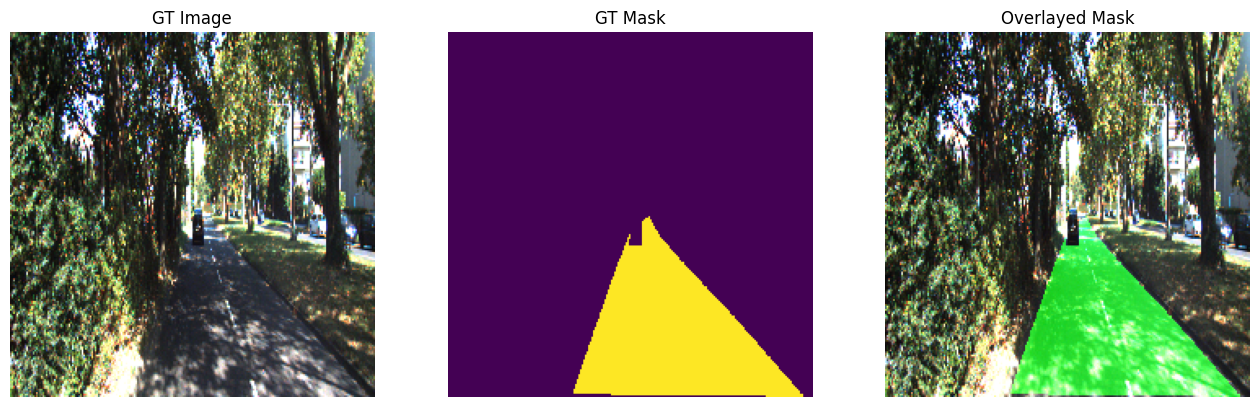

(8, 224, 224, 3)
(8, 224, 224)


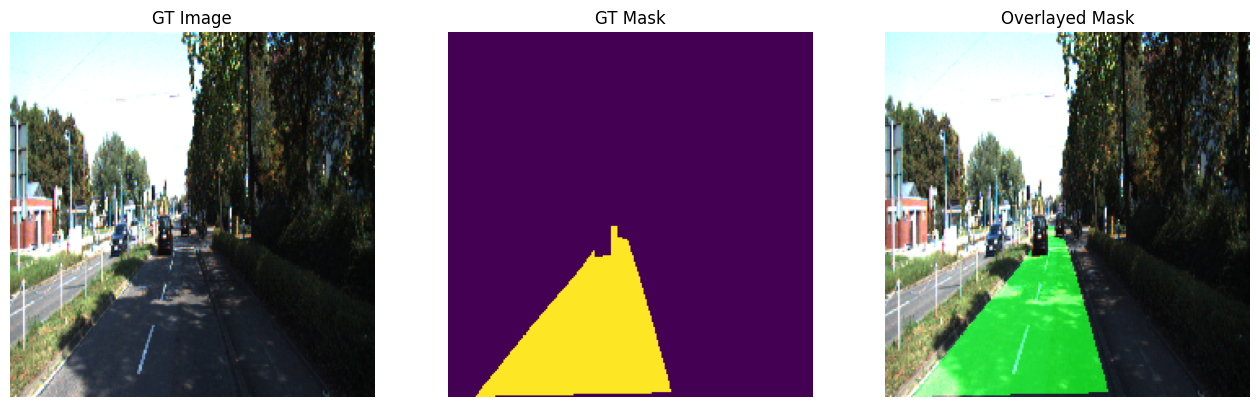

(8, 224, 224, 3)
(8, 224, 224)


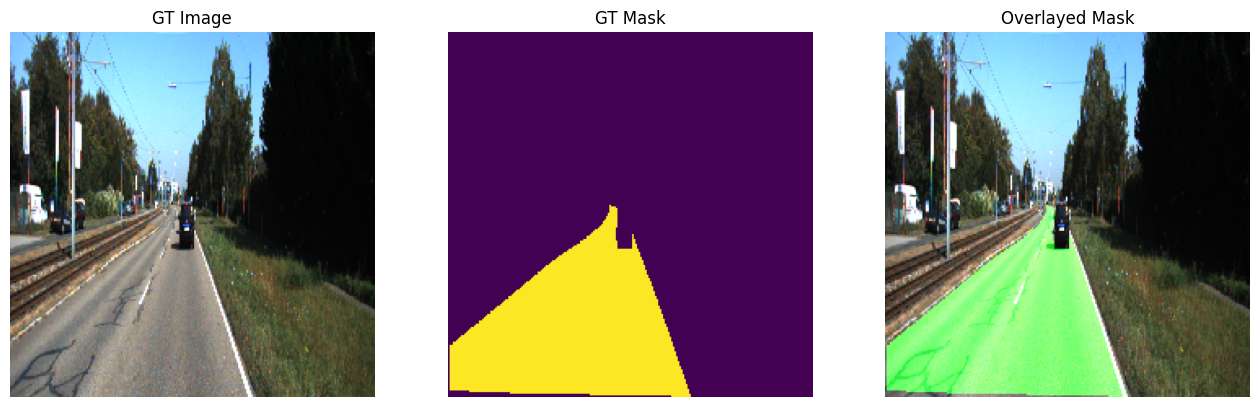

(8, 224, 224, 3)
(8, 224, 224)


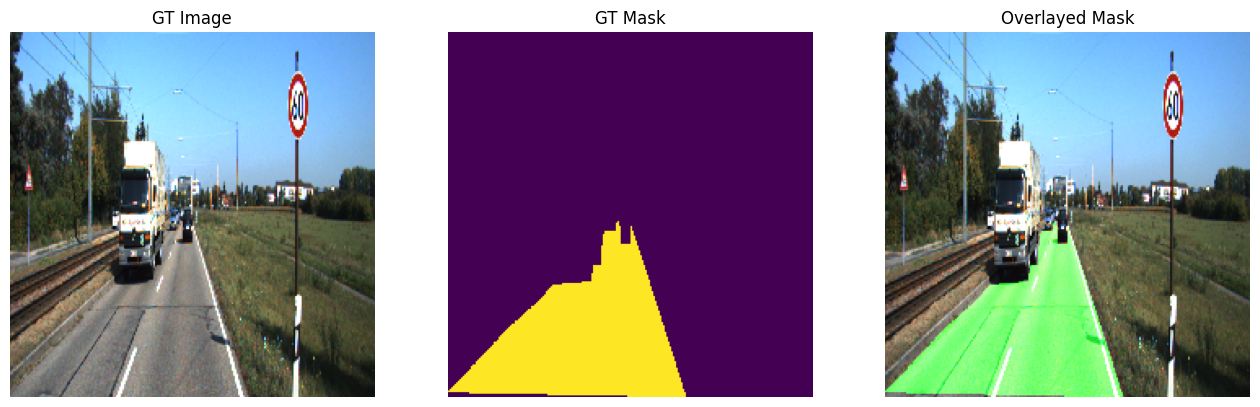

(8, 224, 224, 3)
(8, 224, 224)


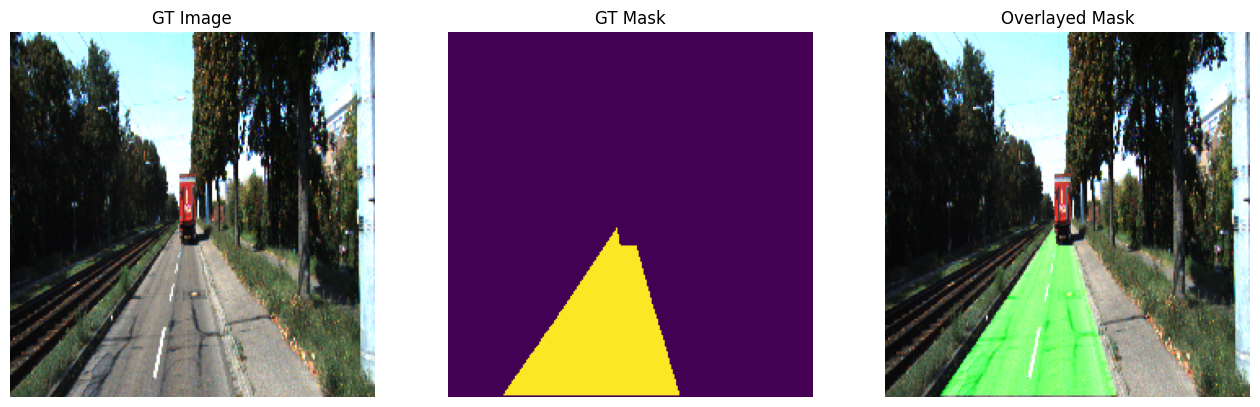

(8, 224, 224, 3)
(8, 224, 224)


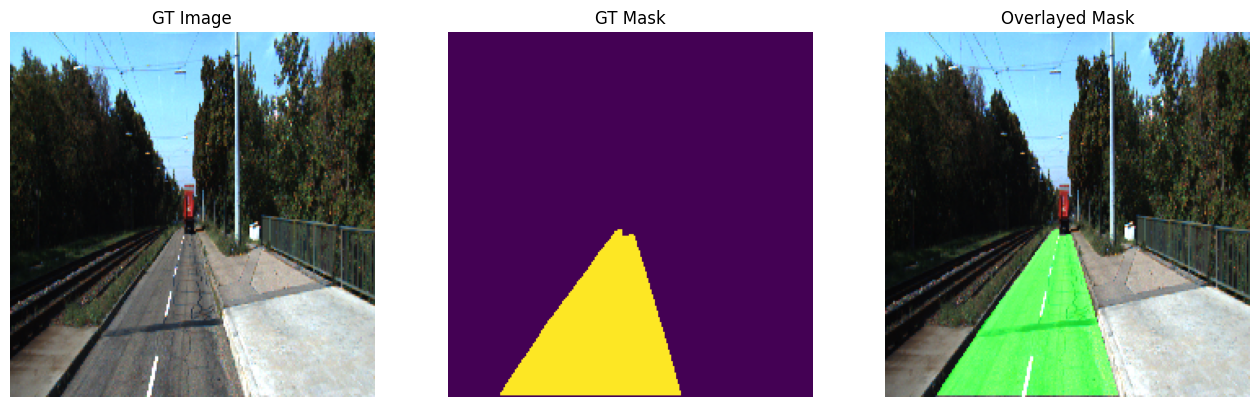

(8, 224, 224, 3)
(8, 224, 224)


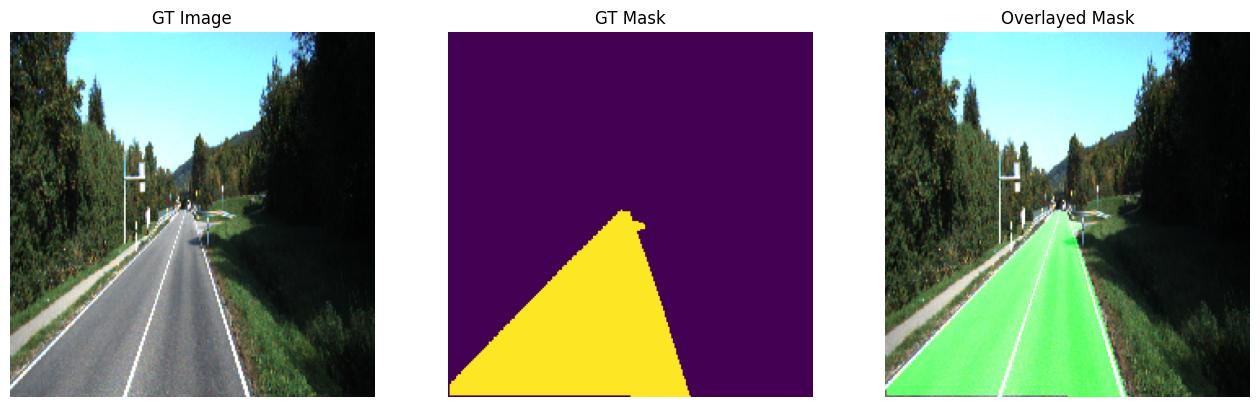

(8, 224, 224, 3)
(8, 224, 224)


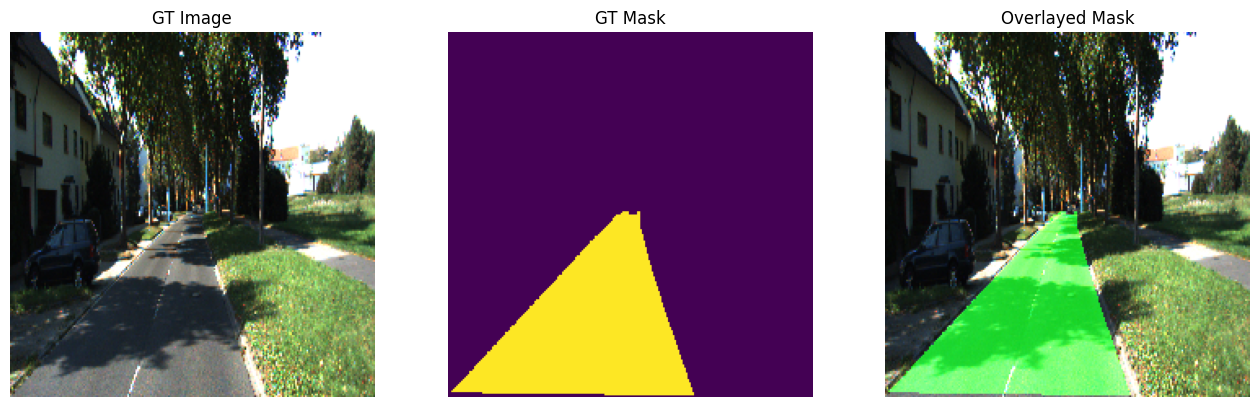

(8, 224, 224, 3)
(8, 224, 224)


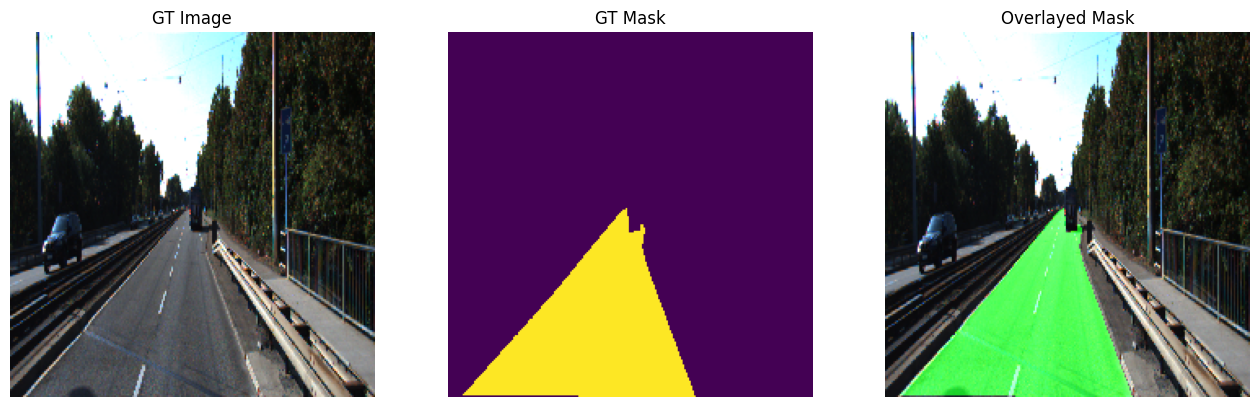

(8, 224, 224, 3)
(8, 224, 224)


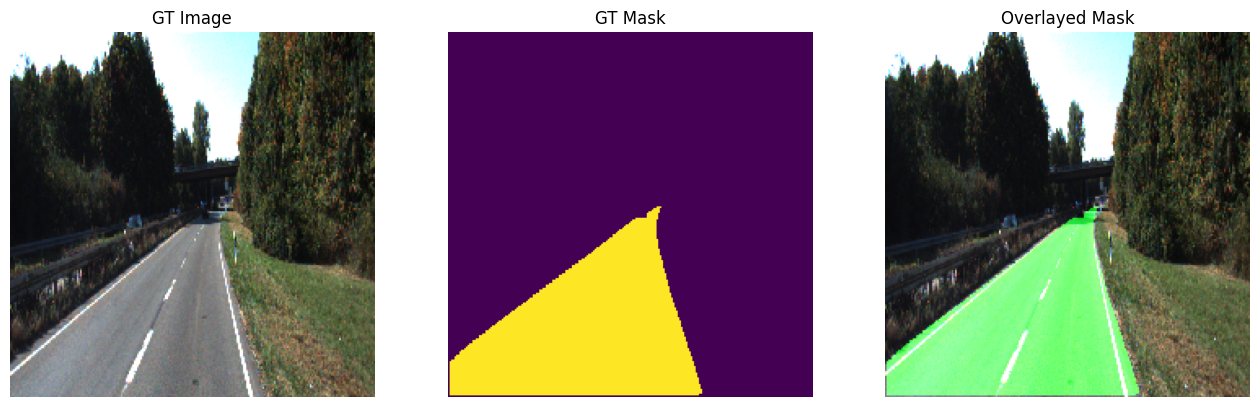

In [24]:
for i, (images, masks) in enumerate(train_dataset):
    if i == 10:
        break
    print(images.shape)
    print(masks.shape)
    # Retrieve last image in data batch as an example.
    image, mask = images[-1], masks[-1]
    display_image_and_mask(
        [image, mask], colour_mapping=classID_to_colour_overlay, colour_mask=False
    )

## Custom Accuracy Metrics

### Mean Pixel Accuracy

Mean Pixel Accuracy is a fraction of pixels correctly classified across all classes and images in a batch. 

In [17]:
def mean_pixel_accuracy(y_true, y_pred) -> float:
    """
    Calculates the Mean Pixel Accuracy of the entire dataset.

    :param y_true: Ground truth mask. Shape: (batch_size, img_height, img_weight)
    Sparse representation of segmentation mask.
    :type y_true: np.ndarray or torch.Tensor

    :param y_pred: Prediction from the model with or without softmax.
    Shape: (batch_size, img_height, img_width, num_classes).
    :type y_pred: np.ndarray or torch.Tensor

    :return: Mean pixel accuracy metric.
    :rtype: float
    """

    # Get the dynamic shape of the prediction tensor.
    shape_pred = tf.shape(y_pred)
    num_classes = y_pred.shape[-1]
    num_pixels = tf.cast(shape_pred[1] * shape_pred[2], tf.float32)

    # Convert the single channel (sparse) ground truth labels to
    # one-hot encoding for metric computation.
    y_true = tf.one_hot(tf.cast(y_true, tf.int32), num_classes, axis=-1)

    # Convert multi-channel predicted output to one-hot encoded thresholded
    # output for metric computation.
    y_pred = tf.one_hot(tf.math.argmax(y_pred, axis=-1), num_classes, axis=-1)

    # Intersection (number of correctly predicted pixels): |G ∩ P|. Shape: (batch_size,).
    # Axes for height, width and num_classes.
    intersection = tf.math.reduce_sum(y_true * y_pred, axis=(1, 2, 3))

    # Accuracy: (number of correctly predicted) / num_pixels. The mean across all batches.
    return tf.math.reduce_mean(intersection / num_pixels, axis=0)

### Mean IoU Metric

Intersection Over Union (IoU) is a metric often used in segmentation problems to access the model's accuracy. It provided a more intuitive basis for accuracy that is not baised by the (unbalanced) percentage of pixels from any particular class. Given two segmentation masks $A$ and $B$, the IoU is defined as:

$$
IoU = \frac{|A \cap B\hspace{1mm}|}{|A \cup B \hspace{1mm}|} \hspace{2mm}
$$

When there are multiple classes and interfaces, we access the model's performance by computating the mean IoU. However, there are two ways in which mean IoU can be computed. The first method below,  shows one approach. 

- Naive Appcroach: The computation for the mean IoU is performed across all the classes in the dataset regardless if they are contained in the ground truth mask or the predicted segmentation map. This approach can lead to an inflated metric computation when the number of classes is greater than two, and the ground truth mask and the predicted segmentation map contain a subset of the total number of classes. Fuction: `mean_iou_naive()`

- Classwise Approach: In this approach, the mean IoU is computed by one considerung the classes that are present in the grouth truth mask or the predicted segmentation map. This computation is a better representation for the metric since it only considers the relevant classes. Function: `mean_iou()`

In [18]:
def mean_iou_naive(y_true, y_pred) -> float:
    """
    Calculates the naive approach of mean IoU of the entire dataset.

    :param y_true: Ground truth mask. Shape: (batch_size, img_height, img_weight)
    Sparse representation of segmentation mask.
    :type y_true: np.ndarray or torch.Tensor

    :param y_pred: Prediction from the model with or without softmax.
    Shape: (batch_size, img_height, img_width, num_classes).
    :type y_pred: np.ndarray or torch.Tensor

    :return: Mean pixel accuracy metric.
    :rtype: float
    """

    num_classes = y_pred.shape[-1]

    # Convert the single channel (sparse) ground truth labels to
    # one-hot encoding for metric computation.
    y_true = tf.one_hot(tf.cast(y_true, tf.int32), num_classes, axis=-1)

    # Convert multi-channel predicted output to one-hot encoded thresholded
    # output for metric computation.
    y_pred = tf.one_hot(tf.math.argmax(y_pred, axis=-1), num_classes, axis=-1)

    # Axes for height, width.
    axes = (1, 2)

    # Intersection (number of correctly predicted pixels): |G ∩ P|. Shape: (batch_size,).
    intersection = tf.math.reduce_sum(y_true * y_pred, axis=axes)

    # Total Sum: |G| + |P|. Shape: (batch_size, num_classes)
    total = tf.math.reduce_sum(y_true, axis=axes) + tf.math.reduce_sum(
        y_pred, axis=axes
    )

    # Union. Shape: (batch_size, num_classes)
    union = total - intersection

    # IoU. Shape: (batch_size, num_classes)
    smooth = 1e-6
    iou = (intersection + smooth) / (union + smooth)

    # Compute the mean over the remaining axes (batch and classes)
    return tf.math.reduce_mean(iou)

In [19]:
def mean_iou(y_true, y_pred) -> float:
    """
    Calculates the classwise approach of mean IoU of the entire dataset.

    :param y_true: Ground truth mask. Shape: (batch_size, img_height, img_weight)
    Sparse representation of segmentation mask.
    :type y_true: np.ndarray or torch.Tensor

    :param y_pred: Prediction from the model with or without softmax.
    Shape: (batch_size, img_height, img_width, num_classes).
    :type y_pred: np.ndarray or torch.Tensor

    :return: Mean pixel accuracy metric.
    :rtype: float
    """

    num_classes = y_pred.shape[-1]

    # Convert the single channel (sparse) ground truth labels to
    # one-hot encoding for metric computation.
    y_true = tf.one_hot(tf.cast(y_true, tf.int32), num_classes, axis=-1)

    # Convert multi-channel predicted output to one-hot encoded thresholded
    # output for metric computation.
    y_pred = tf.one_hot(tf.math.argmax(y_pred, axis=-1), num_classes, axis=-1)

    # Axes for height, width.
    axes = (1, 2)

    # Intersection (number of correctly predicted pixels): |G ∩ P|. Shape: (batch_size,).
    intersection = tf.math.reduce_sum(y_true * y_pred, axis=axes)

    # Total Sum: |G| + |P|. Shape: (batch_size, num_classes)
    total = tf.math.reduce_sum(y_true, axis=axes) + tf.math.reduce_sum(
        y_pred, axis=axes
    )

    # Union. Shape: (batch_size, num_classes)
    union = total - intersection

    # A boolean, then converted to float, value for each class if it is present.
    # Shape: (batch_size, num_classes)
    is_class_present = tf.cast(tf.math.not_equal(total, 0), dtype=tf.float32)

    # Sum along axis(1) to get number of classes in each image.
    # Shape: (batch_size,)
    num_classes_present = tf.math.reduce_sum(is_class_present, axis=1)

    # Shape: (batch_size, num_classes)
    iou = tf.math.divide_no_nan(intersection, union)

    # IoU per image. Average over the total number of classes
    # present in y_true and y_pred. Shape: (batch_size,)
    iou = tf.math.reduce_sum(iou, axis=1) / num_classes_present

    # Compute mean across the batch axis. Shape: scalar
    return tf.math.reduce_mean(iou)

### Dice Coefficient (F1-Score) 

The Dice Coefficient is another metric that is used in the context of segmentation and is often specifically used as the basis for a loss function for segmentation problems. 

Precision is a measure of how precise the model is in making predicitons (quality or purity of the positive predictions) and Recall considers what missed or describes the completeness of the positive predictions. 

$$
P = \frac{TP}{TP + FP} \hspace{10mm} R = \frac{TP}{TP + FN}
$$

This is the motivation that gave rise to the development of the Dice Coefficient (F1-Score) below, defined as the harmonic mean of the two quantities. 

$$
Dice = (\frac{2}{\frac{1}{P} + \frac{1}{R}}) \hspace{2mm} =  \hspace{2mm} \frac{2TP}{2TP + FP + FN}
$$

The Dice Coefficient is often used as the basic of a loss function for segmentation problems.

In [20]:
def dice_coefficient_loss(y_true, y_pred) -> float:
    """
    Calculates the classwise approach of mean IoU of the entire dataset.

    :param y_true: Ground truth mask. Shape: (batch_size, img_height, img_weight)
    Sparse representation of segmentation mask.
    :type y_true: np.ndarray or torch.Tensor

    :param y_pred: Prediction from the model with or without softmax.
    Shape: (batch_size, img_height, img_width, num_classes).
    :type y_pred: np.ndarray or torch.Tensor

    :return: Mean pixel accuracy metric.
    :rtype: float
    """

    num_classes = y_pred.shape[-1]

    # Convert the single channel (sparse) ground truth labels to
    # one-hot encoding for metric computation.
    y_true = tf.one_hot(tf.cast(y_true, tf.int32), num_classes, axis=-1)

    # Axes for height, width.
    axes = (1, 2)

    # Intersection (number of correctly predicted pixels): |G ∩ P|. Shape: (batch_size,).
    intersection = tf.math.reduce_sum(y_true * y_pred, axis=axes)

    # Total Sum: |G| + |P|. Shape: (batch_size, num_classes)
    total = tf.math.reduce_sum(y_true, axis=axes) + tf.math.reduce_sum(
        y_pred, axis=axes
    )

    eps = 1e-3
    dice_coefficient = (2.0 * intersection + eps) / (total + eps)

    # Compute the mean over the remaining axes (batch and classes).
    dice_coefficient_mean = tf.math.reduce_mean(dice_coefficient)

    # Categorical Cross-Entropy Loss
    cce = keras.losses.categorical_crossentropy(y_true, y_pred)

    return 1.0 - dice_coefficient_mean + cce

## Train the model

In [21]:
model.compile(
    optimizer=Adam(learning_rate=TrainingConfig.LEARNING_RATE),
    loss=dice_coefficient_loss,
    metrics=["accuracy", mean_pixel_accuracy, mean_iou],
)

# Create a new checkpoint directory every time.
if not TrainingConfig.CHECKPOINT_DIR.exists():
    os.makedirs(TrainingConfig.CHECKPOINT_DIR)

num_versions = len(os.listdir(TrainingConfig.CHECKPOINT_DIR)) + 1
version_dir = TrainingConfig.CHECKPOINT_DIR / f"version_{num_versions}"
os.makedirs(version_dir)

# Callback to save the best model based on validation loss.
model_checkpoint_callback = keras.callbacks.ModelCheckpoint(
    filepath=version_dir / "model.keras",
    save_weights_only=False,
    monitor="val_loss",
    mode="auto",
    save_best_only=True,
)

In [22]:
history = model.fit(
    train_dataset,
    epochs=TrainingConfig.EPOCHS,
    verbose=1,
    validation_data=valid_dataset,
    callbacks=[model_checkpoint_callback],
)

Epoch 1/51


ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 of layer "conv2d" is incompatible with the layer: expected axis -1 of input shape to have value 2, but received input with shape (None, 224, 224, 3)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(None, 224, 224, 3), dtype=float32)
  • training=True
  • mask=None
  • kwargs=<class 'inspect._empty'>